# Notebook 09 — Validação, resíduos e SHAP


Dataset: raw_nir_data_Saturin.csv
Amostras de teste: 8775
MAE: 73.5894
RMSE: 102.5932
R2: 0.6033
Resíduo médio: -0.8189
Desvio dos resíduos: 102.5899


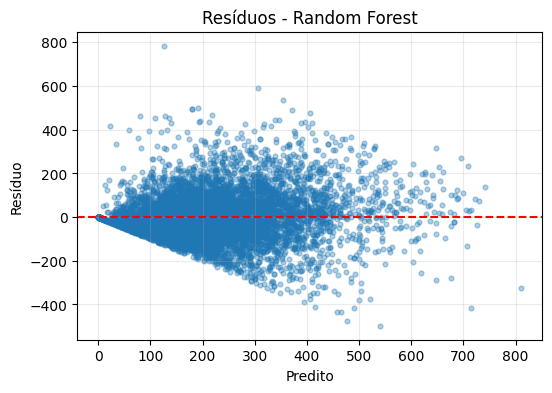

In [2]:
# Validação de resíduos do modelo Random Forest
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
CANDIDATE_FILES = [
    "raw_nir_data_Saturin.csv",
    "raw_mir_data_Saturin.csv",
    "raw_nir_data_saturin.csv",
    "raw_mir_data_saturin.csv",
]


def resolve_dataset():
    for file_name in CANDIDATE_FILES:
        file_path = DATA_DIR / file_name
        if file_path.exists():
            return file_path
    raise FileNotFoundError(f"Arquivo espectral não encontrado em {DATA_DIR}")


def read_csv_robust(file_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(file_path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível decodificar {file_path.name}")


dataset_path = resolve_dataset()
df = read_csv_robust(dataset_path)
df = df.drop(columns=[column for column in df.columns if str(column).lower().startswith("unnamed")], errors="ignore")

spectral_columns = [column for column in df.columns if str(column).lower().startswith("wl_")]
if not spectral_columns:
    for column in df.columns:
        try:
            wavelength = float(str(column).strip().replace(",", "."))
        except (TypeError, ValueError):
            continue
        if 300 <= wavelength <= 4000:
            spectral_columns.append(column)

clay_aliases = {"clay", "clay_gkg", "argila", "argila_gkg"}
clay_column = next(
    (column for column in df.columns if str(column).strip().lower() in clay_aliases),
    None,
)
if not spectral_columns or clay_column is None:
    raise ValueError("Colunas espectrais ou coluna de argila não encontradas.")

X = df[spectral_columns].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df[clay_column], errors="coerce")
valid_rows = X.notna().any(axis=1) & y.notna()
X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()
X = X.fillna(X.median()).fillna(0.0)
X = X.loc[:, X.std(axis=0) > 1e-12]

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
)
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf.fit(Xtr, ytr)
p = rf.predict(Xte)
res = yte.to_numpy() - p

print(f"Dataset: {dataset_path.name}")
print(f"Amostras de teste: {len(yte)}")
print(f"MAE: {mean_absolute_error(yte, p):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(yte, p)):.4f}")
print(f"R2: {r2_score(yte, p):.4f}")
print(f"Resíduo médio: {res.mean():.4f}")
print(f"Desvio dos resíduos: {res.std():.4f}")

plt.figure(figsize=(6, 4))
plt.scatter(p, res, s=12, alpha=0.35)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos - Random Forest")
plt.grid(alpha=0.25)
plt.show()


c:\Users\PC\Desktop\RESET\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


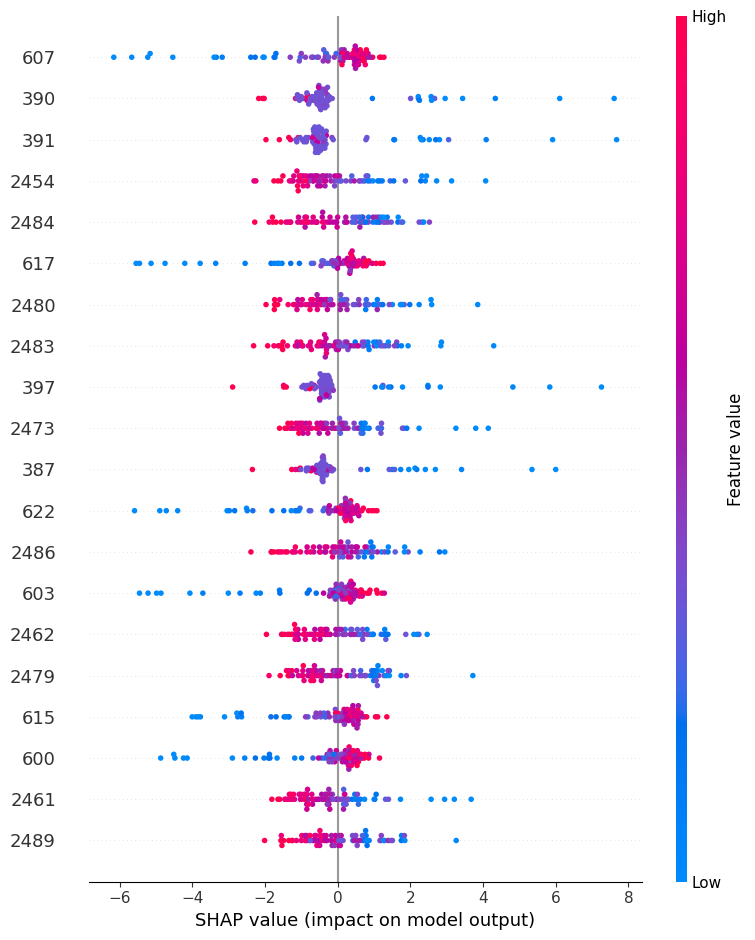

In [4]:
try:
    import shap
    explainer=shap.TreeExplainer(rf)
    sv=explainer.shap_values(Xte.iloc[:80])
    shap.summary_plot(sv,Xte.iloc[:80],show=False)
    plt.tight_layout(); plt.show()
except ImportError:
    print('SHAP não instalado. Instale com: pip install shap')


INTERPRETAÇÃO SHAP
Quanto maior o mean_abs_shap, maior a influência média da banda na previsão. O sinal indica a direção média: positivo aumenta a previsão de argila e negativo reduz.
Amostras interpretadas: 80
Bandas interpretadas: 2151

Bandas mais importantes por influência média:


,band,wavelength,mean_abs_shap,mean_signed_shap
0,607,607.00,1.070983,-0.455185
1,390,390.00,1.044484,0.003390
2,391,391.00,1.028894,-0.020099
3,2454,2454.00,0.973783,-0.066728
4,2484,2484.00,0.946918,0.150138
5,617,617.00,0.911628,-0.345552
6,2480,2480.00,0.902057,0.021882
7,2483,2483.00,0.888552,0.107331
8,397,397.00,0.868620,0.008217
9,2473,2473.00,0.858043,0.032204



Maiores contribuições médias positivas:


,band,wavelength,mean_signed_shap
43,2493,2493.00,0.233896
45,2494,2494.00,0.188047
129,1907,1907.00,0.154830
29,2499,2499.00,0.151377
4,2484,2484.00,0.150138



Maiores contribuições médias negativas:


,band,wavelength,mean_signed_shap
0,607,607.00,-0.455185
11,622,622.00,-0.369196
31,604,604.00,-0.352387
5,617,617.00,-0.345552
40,608,608.00,-0.344639


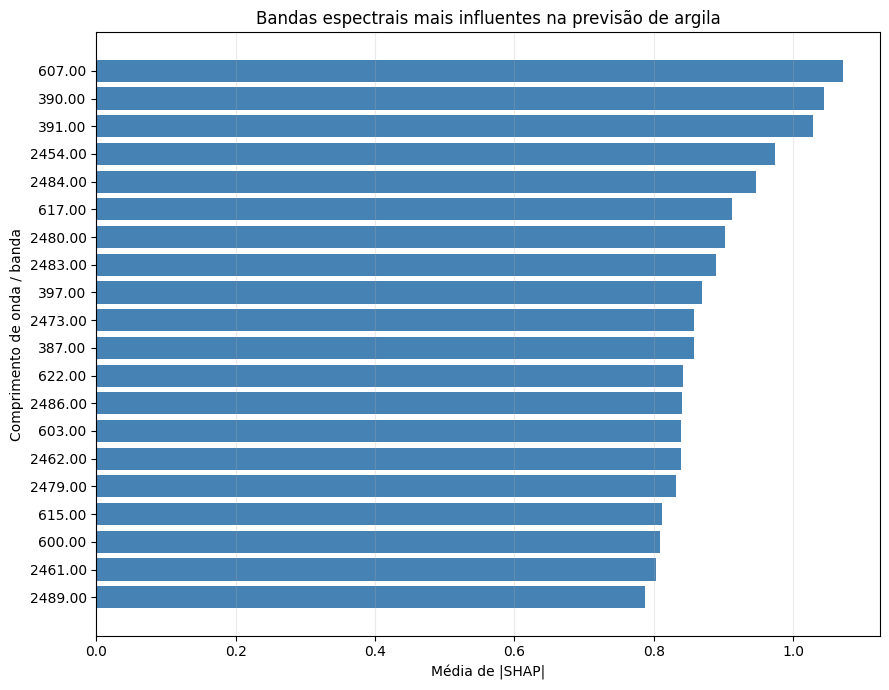

Conclusão: o modelo Random Forest utiliza principalmente as bandas listadas acima. Essas bandas são relevantes para a previsão, mas a importância SHAP não prova, sozinha, uma relação causal ou uma assinatura química específica.


In [5]:
# Interpretação dos valores SHAP
# Os valores SHAP indicam quanto cada banda altera a previsão em relação à previsão média do modelo.
if "sv" not in globals() or "Xte" not in globals():
    print("Os valores SHAP ainda não estão disponíveis. Execute a célula SHAP acima primeiro.")
else:
    shap_values = np.asarray(sv)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    shap_input = Xte.iloc[:shap_values.shape[0]].copy()
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    mean_signed_shap = shap_values.mean(axis=0)

    # Converte o nome da coluna para comprimento de onda quando possível.
    def wavelength_label(column):
        text = str(column).replace("wl_", "").replace(",", ".")
        try:
            return f"{float(text):.2f}"
        except ValueError:
            return str(column)

    shap_importance = pd.DataFrame({
        "band": shap_input.columns,
        "wavelength": [wavelength_label(column) for column in shap_input.columns],
        "mean_abs_shap": mean_abs_shap,
        "mean_signed_shap": mean_signed_shap,
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    top_n = min(20, len(shap_importance))
    top_features = shap_importance.head(top_n).copy()
    positive_features = shap_importance.sort_values("mean_signed_shap", ascending=False).head(5)
    negative_features = shap_importance.sort_values("mean_signed_shap", ascending=True).head(5)

    print("INTERPRETAÇÃO SHAP")
    print("=" * 35)
    print(
        "Quanto maior o mean_abs_shap, maior a influência média da banda na previsão. "
        "O sinal indica a direção média: positivo aumenta a previsão de argila e negativo reduz."
    )
    print(f"Amostras interpretadas: {shap_input.shape[0]}")
    print(f"Bandas interpretadas: {shap_input.shape[1]}")
    print("\nBandas mais importantes por influência média:")
    display(top_features[["band", "wavelength", "mean_abs_shap", "mean_signed_shap"]].round(6))

    print("\nMaiores contribuições médias positivas:")
    display(positive_features[["band", "wavelength", "mean_signed_shap"]].round(6))
    print("\nMaiores contribuições médias negativas:")
    display(negative_features[["band", "wavelength", "mean_signed_shap"]].round(6))

    # Gráfico horizontal das bandas com maior influência média.
    plot_features = top_features.sort_values("mean_abs_shap")
    plt.figure(figsize=(9, 7))
    plt.barh(plot_features["wavelength"], plot_features["mean_abs_shap"], color="steelblue")
    plt.xlabel("Média de |SHAP|")
    plt.ylabel("Comprimento de onda / banda")
    plt.title("Bandas espectrais mais influentes na previsão de argila")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(
        "Conclusão: o modelo Random Forest utiliza principalmente as bandas listadas acima. "
        "Essas bandas são relevantes para a previsão, mas a importância SHAP não prova, sozinha, "
        "uma relação causal ou uma assinatura química específica."
    )





### Interpretação do gráfico SHAP

O gráfico mostra as bandas espectrais mais importantes para prever o teor de argila usando Random Forest. Quanto maior a barra, maior a influência média da banda na previsão.

Principais bandas:

- **607 nm**: maior importância média, com influência predominantemente negativa.
- **390–397 nm**: forte contribuição na previsão.
- **603–622 nm**: grupo importante, geralmente associado a contribuições negativas.
- **2460–2490 nm**: região MIR com várias bandas relevantes e contribuições predominantemente positivas.
- **2454 nm**: também apresenta alta importância, com influência média negativa.

A banda de **607 nm** possui o maior valor médio de $|SHAP|$, indicando que o modelo utiliza fortemente essa região para diferenciar os teores de argila. As bandas próximas a **2480–2490 nm** também formam um conjunto importante de informações espectrais.

O sinal SHAP indica a direção média:

- SHAP positivo: aumenta a previsão de argila.
- SHAP negativo: reduz a previsão de argila.
- $|SHAP|$ alto: maior influência, independentemente da direção.

Essas bandas são importantes para o modelo, mas a análise SHAP não prova, sozinha, uma relação química causal.
